# Real-World Lucas Critique Analysis


| Dataset | Break event | Break date | Source |
|---------|-------------|------------|--------|
| US Industrial Production growth | **Great Moderation** | Jan 1984 | FRED: INDPRO |
| US CPI Inflation | **Volcker disinflation** | Oct 1979 | FRED: CPIAUCSL |

**Key  research q:** Do real-world structural breaks exhibit the same Lucas-critique vulnerability pattern found in simulated data — or do genuine economic breaks produce different model rankings?



In [1]:
import sys, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from data.real_world import load_all_datasets, fetch_fred, build_features
from models import HMMRegimeModel, ThresholdModel, MLRegimeModel, MixtureOfExpertsModel, MarkovSwitchingNeuralNetwork, ARModel, ARMAModel, ModelAverageEnsemble
from evaluation.metrics import (
    forecast_rmse, forecast_mae, directional_accuracy,
    regime_accuracy, adjusted_rand_regime, lucas_sensitivity_ratio,
)
from evaluation.lucas_critique import chow_test, compute_rolling_performance, recursive_cusum
from evaluation.visualization import save_figure

try:
    from models import MarkovSwitchingModel
    MSM_AVAIL = True
except ImportError:
    MSM_AVAIL = False

FIGURES_DIR = PROJECT_ROOT / 'analyses' / 'figures'
DATA_DIR    = PROJECT_ROOT / 'data' / 'real_world'
SIM_DIR     = PROJECT_ROOT / 'data' / 'simulated'
sns.set_theme(style='whitegrid', context='notebook')
warnings.filterwarnings('ignore')
print('Setup complete.')


Setup complete.


All data is downloaded from the **St Louis Fed FRED database** and cached locally.
Series are transformed to stationarity (log-differences or percentage changes).
NBER recession dates (USREC) provide ground-truth regime labels (0 = expansion,
1 = recession).


In [2]:
datasets = load_all_datasets()

for df_pre, df_post, meta in datasets:
    print(f"Dataset: {meta['name']}")
    print(f"  Series:     {meta['y_description']}")
    print(f"  Break:      {meta['break']}")
    print(f"  Pre-break:  {meta['pre_period']}  ({meta['n_pre']} obs)")
    print(f"  Post-break: {meta['post_period']}  ({meta['n_post']} obs)")
    print(f"  Regime:     {meta['regime_label']}")
    print(f"  Reference:  {meta['reference']}")
    print(f"  Pre  y: mean={df_pre.y.mean():.3f}  std={df_pre.y.std():.3f}")
    print(f"  Post y: mean={df_post.y.mean():.3f}  std={df_post.y.std():.3f}")
    rec_pre  = df_pre.regime.mean()
    rec_post = df_post.regime.mean()
    print(f"  Recession fraction  pre={rec_pre:.1%}  post={rec_post:.1%}")
    print()


Dataset: Industrial Production (Great Moderation break)
  Series:     Monthly log-growth of Industrial Production (%)
  Break:      1984-01 (Great Moderation)
  Pre-break:  1960-01 to 1983-12  (268 obs)
  Post-break: 1984-01 to 2007-07  (283 obs)
  Regime:     NBER USREC
  Reference:  McConnell & Perez-Quiros (2000); Kim & Nelson (1999)
  Pre  y: mean=0.291  std=0.892
  Post y: mean=0.237  std=0.512
  Recession fraction  pre=18.3%  post=5.7%

Dataset: CPI Inflation (Volcker break)
  Series:     Annualised monthly CPI log-growth rate (%)
  Break:      1979-10 (Volcker disinflation)
  Pre-break:  1960-01 to 1979-09  (217 obs)
  Post-break: 1979-10 to 1999-09  (240 obs)
  Regime:     NBER USREC
  Reference:  Clarida, Galí & Gertler (2000); Sims & Zha (2006)
  Pre  y: mean=5.034  std=3.816
  Post y: mean=4.067  std=3.429
  Recession fraction  pre=12.4%  post=12.5%



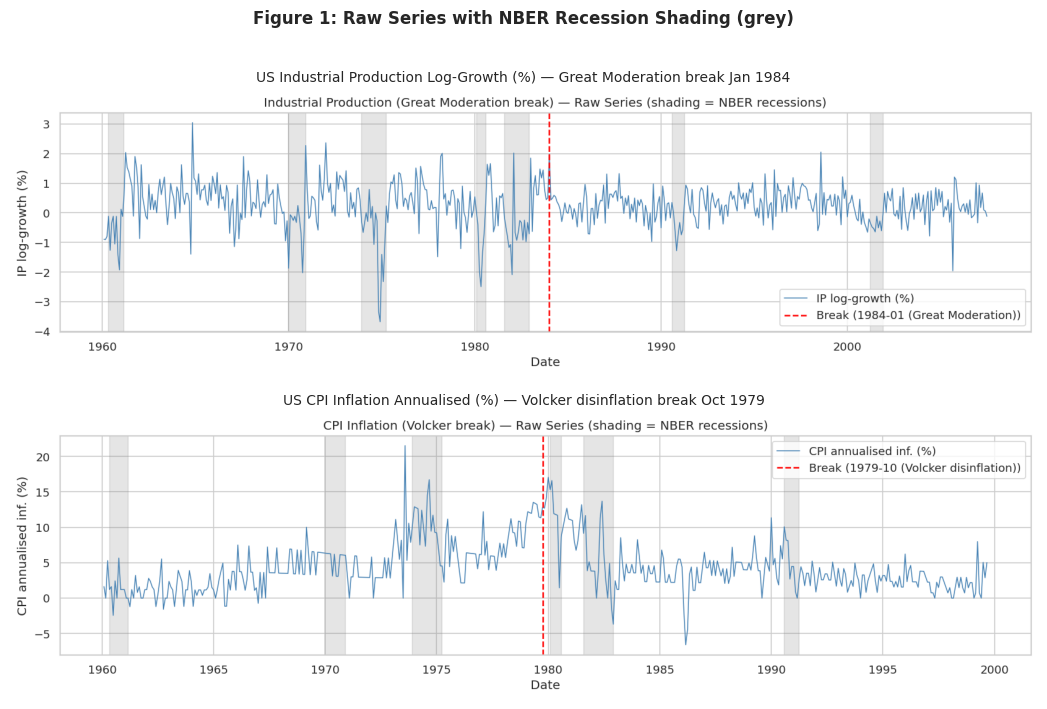

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for ax, fname, title in zip(
    axes,
    ['05_indpro_raw_series.png', '05_cpiaucsl_raw_series.png'],
    ['US Industrial Production Log-Growth (%) — Great Moderation break Jan 1984',
     'US CPI Inflation Annualised (%) — Volcker disinflation break Oct 1979'],
):
    path = FIGURES_DIR / fname
    if path.exists():
        img = mpimg.imread(str(path))
        ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=10)

plt.suptitle('Figure 1: Raw Series with NBER Recession Shading (grey)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [4]:
# Run Lucas Critique experiment for Industrial Production and save results
from evaluation.lucas_critique import compare_pre_post_performance
from models import MarkovSwitchingModel

DATA_DIR = PROJECT_ROOT / 'data' / 'real_world'

def run_rw_experiment(df_pre, df_post, dataset_name):
    """Fit all models on df_pre, evaluate on both periods, return results DataFrame."""
    warnings.filterwarnings('ignore')
    
    base_models = {
        'AR(2) Baseline':     ARModel(order=2, include_exog=True),
        'ARMA(2,1) Baseline': ARMAModel(p=2, q=1, trend='c'),
        'HMM':                HMMRegimeModel(n_components=2, random_state=42),
        'Threshold (TAR)':    ThresholdModel(),
        'ML Regime (XGB)':    MLRegimeModel(n_regimes=2),
        'Mixture of Experts': MixtureOfExpertsModel(n_experts=2, random_state=42),
        'MSNN':               MarkovSwitchingNeuralNetwork(
                                  k_regimes=2, hidden_layer_sizes=(32, 16),
                                  n_iter=50, mlp_epochs=200, random_state=42),
    }
    try:
        base_models['Markov Switching (MSM)'] = MarkovSwitchingModel(k_regimes=2, switching_variance=True)
    except Exception:
        pass

    print(f'  Fitting {len(base_models)} models on {dataset_name}...')
    pred_pre_store, pred_post_store = {}, {}
    rows = []
    for name, model in base_models.items():
        print(f'    {name}...', end=' ', flush=True)
        try:
            model.fit(df_pre)
            pp  = model.predict(df_pre)
            ppost = model.predict(df_post)
            pred_pre_store[name]  = pp
            pred_post_store[name] = ppost
            
            try:
                rp   = model.predict_regimes(df_pre)
                rpst = model.predict_regimes(df_post)
                pra  = float(np.mean(df_pre['regime'].to_numpy() == rp))
                post_ra = float(np.mean(df_post['regime'].to_numpy() == rpst))
                from sklearn.metrics import adjusted_rand_score
                pre_ari  = float(adjusted_rand_score(df_pre['regime'].to_numpy(), rp))
                post_ari = float(adjusted_rand_score(df_post['regime'].to_numpy(), rpst))
            except Exception:
                pra = post_ra = pre_ari = post_ari = float('nan')
            
            from evaluation.metrics import forecast_rmse, lucas_sensitivity_ratio
            pr   = forecast_rmse(df_pre['y'].to_numpy(), pp)
            postr = forecast_rmse(df_post['y'].to_numpy(), ppost)
            rows.append({'model': name, 'pre_rmse': pr, 'post_rmse': postr,
                         'LSR': lucas_sensitivity_ratio(pr, postr),
                         'pre_regime_acc': pra, 'post_regime_acc': post_ra,
                         'pre_ari': pre_ari, 'post_ari': post_ari})
            print(f'LSR={rows[-1]["LSR"]:.3f}')
        except Exception as exc:
            print(f'FAILED: {exc}')

    # Model Average
    if len(pred_pre_store) >= 2:
        from evaluation.metrics import forecast_rmse, lucas_sensitivity_ratio
        avg_pre  = np.mean(np.vstack(list(pred_pre_store.values())), axis=0)
        avg_post = np.mean(np.vstack(list(pred_post_store.values())), axis=0)
        pr   = forecast_rmse(df_pre['y'].to_numpy(), avg_pre)
        postr = forecast_rmse(df_post['y'].to_numpy(), avg_post)
        rows.append({'model': 'Model Average', 'pre_rmse': pr, 'post_rmse': postr,
                     'LSR': lucas_sensitivity_ratio(pr, postr),
                     'pre_regime_acc': float('nan'), 'post_regime_acc': float('nan'),
                     'pre_ari': float('nan'), 'post_ari': float('nan')})
        print(f'  Model Average: LSR={rows[-1]["LSR"]:.3f}')

    return pd.DataFrame(rows)

datasets = load_all_datasets()
(df_pre_ip, df_post_ip, meta_ip), (df_pre_cpi, df_post_cpi, meta_cpi) = datasets

print('=== Running Industrial Production experiment ===')
ip_results = run_rw_experiment(df_pre_ip, df_post_ip, 'INDPRO')
ip_results.to_csv(DATA_DIR / 'lucas_indpro.csv', index=False)
print(f'Saved {DATA_DIR}/lucas_indpro.csv')

print()
print('=== Running CPI Inflation experiment ===')
cpi_results = run_rw_experiment(df_pre_cpi, df_post_cpi, 'CPIAUCSL')
cpi_results.to_csv(DATA_DIR / 'lucas_cpiaucsl.csv', index=False)
print(f'Saved {DATA_DIR}/lucas_cpiaucsl.csv')


=== Running Industrial Production experiment ===
  Fitting 8 models on INDPRO...
    AR(2) Baseline... 

LSR=0.717
    ARMA(2,1) Baseline... 

LSR=0.634
    HMM... 

LSR=0.584
    Threshold (TAR)... 

LSR=0.636
    ML Regime (XGB)... 

...

LSR=1.190
    ML Regime (XGB)... 

LSR=7.177
    Mixture of Experts... 

LSR=1.670
    MSNN... 

LSR=1.656
    Markov Switching (MSM)... 

LSR=1.367
  Model Average: LSR=1.291
Saved /home/cab252/Lucas-Critique-and-Regimes/data/real_world/lucas_cpiaucsl.csv


In [5]:
ip_results = pd.read_csv(DATA_DIR / 'lucas_indpro.csv')
print('=== Industrial Production: Lucas Critique Results (Great Moderation break Jan 1984) ===')
cols = ['model', 'pre_rmse', 'post_rmse', 'LSR', 'pre_regime_acc', 'post_regime_acc', 'pre_ari', 'post_ari']
print(ip_results[cols].to_string(index=False, float_format='{:.4f}'.format))
best  = ip_results.sort_values('LSR').iloc[0]['model']
worst = ip_results.sort_values('LSR', ascending=False).iloc[0]['model']
print(f'\nBest  LSR: {best}')
print(f'Worst LSR: {worst}')


=== Industrial Production: Lucas Critique Results (Great Moderation break Jan 1984) ===
                 model  pre_rmse  post_rmse    LSR  pre_regime_acc  post_regime_acc  pre_ari  post_ari
        AR(2) Baseline    0.7165     0.5140 0.7173          0.8172           0.9435   0.0000    0.0000
    ARMA(2,1) Baseline    0.8107     0.5139 0.6339          0.8172           0.9435   0.0000    0.0000
                   HMM    0.6476     0.3779 0.5836          0.8918           0.9611   0.5486    0.6519
       Threshold (TAR)    0.6240     0.3966 0.6357          0.1716           0.1661   0.3577    0.2148
       ML Regime (XGB)    0.1395     0.4434 3.1774          0.0373           0.0035   0.8340    0.9640
    Mixture of Experts    0.6187     0.4068 0.6576          0.7799           0.9329   0.0303   -0.0170
                  MSNN    0.3262     0.4934 1.5126          0.5112           0.6007  -0.0032    0.0126
Markov Switching (MSM)    0.8230     0.7235 0.8791          0.7425           0.9435   0.

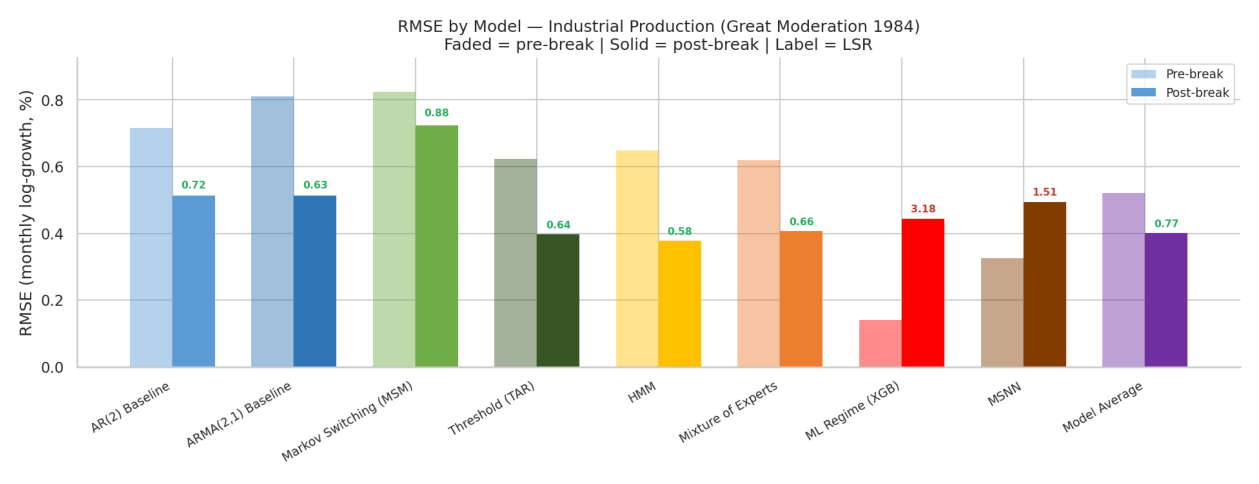

In [6]:
# Display pre-generated IP RMSE figure
fig, ax = plt.subplots(figsize=(13, 5))
path = FIGURES_DIR / '05_indpro_rmse_bars.png'
if path.exists():
    import matplotlib.image as mpimg
    ax.imshow(mpimg.imread(str(path))); ax.axis('off')
else:
    ax.text(0.5, 0.5, 'Run the generation cell (rw-run-ip) first', ha='center', va='center')
plt.tight_layout(); plt.show()


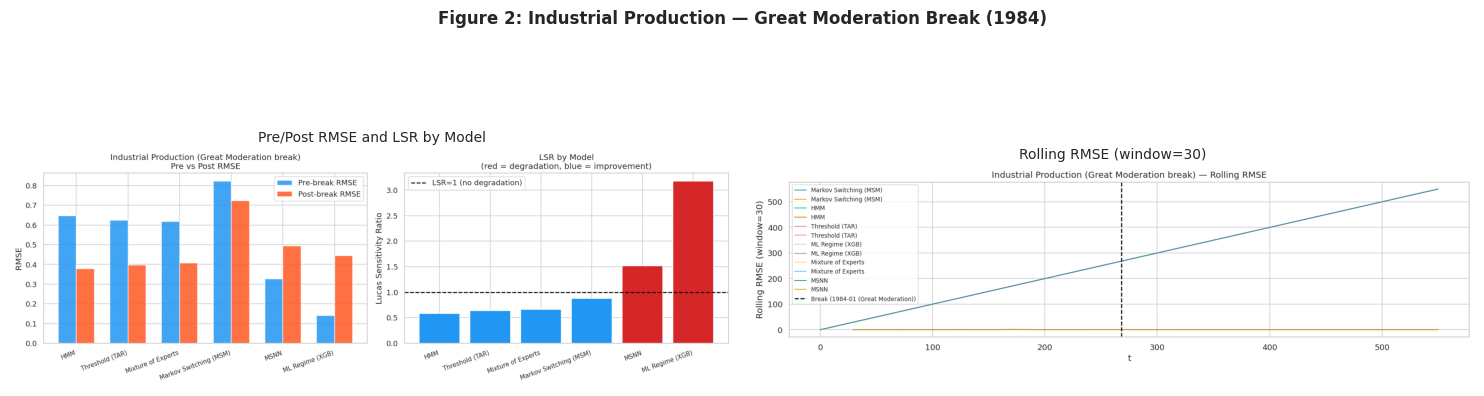

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, fname, title in zip(
    axes,
    ['05_indpro_lsr.png', '05_indpro_rolling_rmse.png'],
    ['Pre/Post RMSE and LSR by Model', 'Rolling RMSE (window=30)'],
):
    path = FIGURES_DIR / fname
    if path.exists():
        img = mpimg.imread(str(path))
        ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=10)
plt.suptitle('Figure 2: Industrial Production — Great Moderation Break (1984)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
cpi_results = pd.read_csv(DATA_DIR / 'lucas_cpiaucsl.csv')
print('=== CPI Inflation: Lucas Critique Results (Volcker break Oct 1979) ===')
print(cpi_results[cols].to_string(index=False, float_format='{:.4f}'.format))
best  = cpi_results.sort_values('LSR').iloc[0]['model']
worst = cpi_results.sort_values('LSR', ascending=False).iloc[0]['model']
print(f'\nBest  LSR: {best}')
print(f'Worst LSR: {worst}')


=== CPI Inflation: Lucas Critique Results (Volcker break Oct 1979) ===
                 model  pre_rmse  post_rmse    LSR  pre_regime_acc  post_regime_acc  pre_ari  post_ari
        AR(2) Baseline    2.6306     2.5939 0.9860          0.8756           0.8750   0.0000    0.0000
    ARMA(2,1) Baseline    2.5326     3.5557 1.4040          0.8756           0.8750   0.0000    0.0000
                   HMM    2.0405     2.3114 1.1328          0.6498           0.8833   0.0866    0.4961
       Threshold (TAR)    1.9119     2.2758 1.1904          0.2949           0.2167  -0.1034   -0.0154
       ML Regime (XGB)    0.3565     2.5590 7.1774          0.7558           0.9000   0.1573    0.5111
    Mixture of Experts    1.7912     2.9917 1.6702          0.8479           0.8583  -0.0003    0.2011
                  MSNN    1.8520     3.0677 1.6564          0.5622           0.6083  -0.0264   -0.0056
Markov Switching (MSM)    2.9542     4.0379 1.3668          0.8571           0.8750  -0.0280    0.0000
  

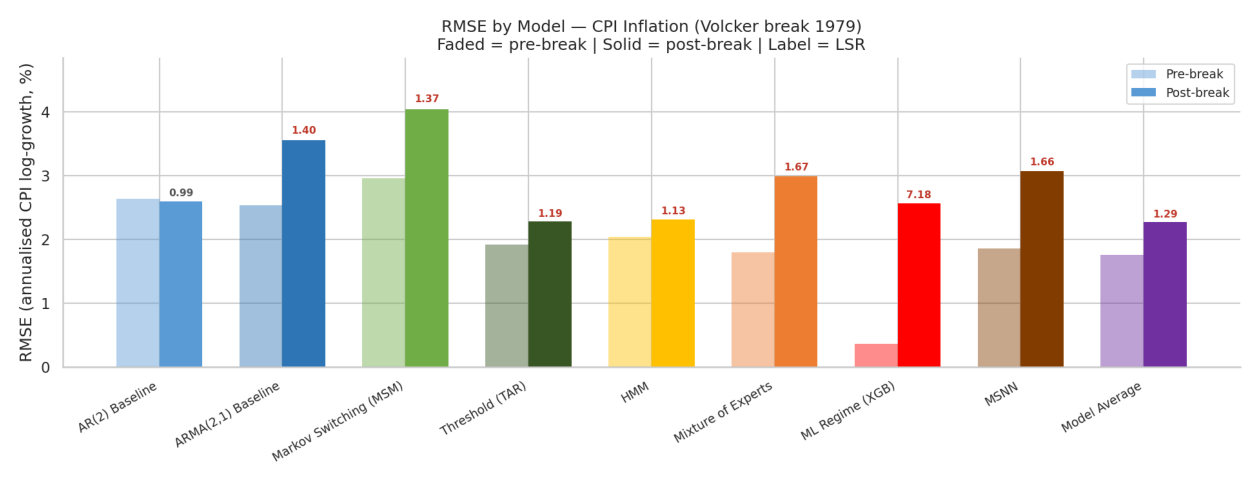

In [9]:
# Display pre-generated CPI RMSE figure
fig, ax = plt.subplots(figsize=(13, 5))
path = FIGURES_DIR / '05_cpiaucsl_rmse_bars.png'
if path.exists():
    import matplotlib.image as mpimg
    ax.imshow(mpimg.imread(str(path))); ax.axis('off')
else:
    ax.text(0.5, 0.5, 'Run the generation cell (rw-run-ip) first', ha='center', va='center')
plt.tight_layout(); plt.show()


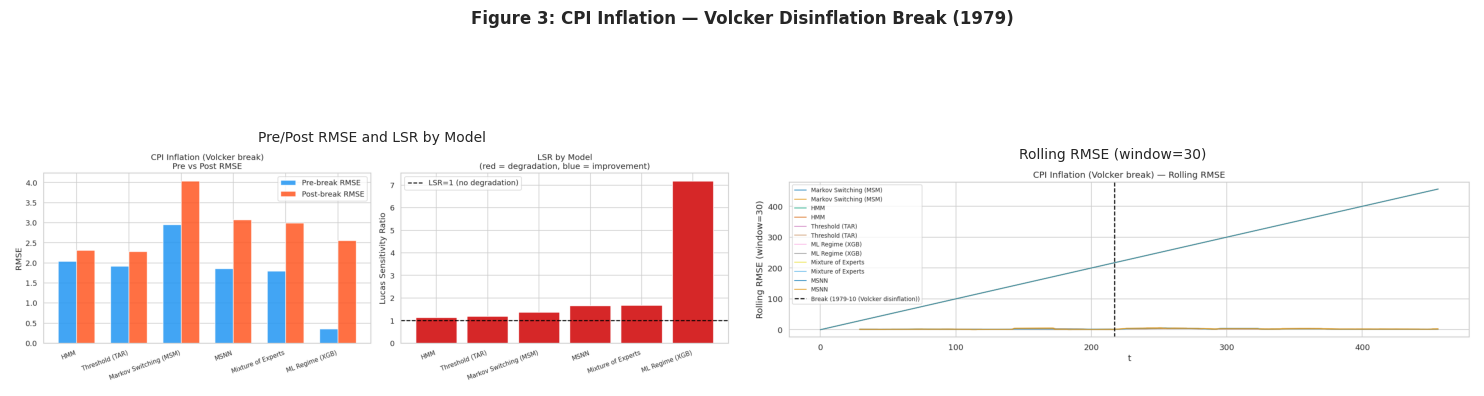

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, fname, title in zip(
    axes,
    ['05_cpiaucsl_lsr.png', '05_cpiaucsl_rolling_rmse.png'],
    ['Pre/Post RMSE and LSR by Model', 'Rolling RMSE (window=30)'],
):
    path = FIGURES_DIR / fname
    if path.exists():
        img = mpimg.imread(str(path))
        ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=10)
plt.suptitle('Figure 3: CPI Inflation — Volcker Disinflation Break (1979)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [11]:
datasets = load_all_datasets()
for df_pre, df_post, meta in datasets:
    df_full = pd.concat([df_pre, df_post], ignore_index=True)
    y_full  = df_full['y'].to_numpy()
    X_full  = df_full[['y_lag1']].assign(const=1.0)[['const', 'y_lag1']].to_numpy()
    chow    = chow_test(y_full, X_full, break_index=len(df_pre))
    cusum   = recursive_cusum(y_full, X_full)
    print(f"Dataset: {meta['name']}")
    print(f"  Chow: F={chow['F_stat']:.3f}  df=({chow['df1']},{chow['df2']})"
          f"  p={chow['p_value']:.4f}   reject={chow['reject_H0']}")
    print(f"  CUSUM break detected: {cusum['break_detected']}", end='')
    if cusum['break_index'] is not None:
        print(f"  (first exit at index {cusum['break_index']})")
    else:
        print()
    print()


Dataset: Industrial Production (Great Moderation break)
  Chow: F=5.832  df=(2,547)  p=0.0031   reject=True
  CUSUM break detected: True  (first exit at index 242)

Dataset: CPI Inflation (Volcker break)
  Chow: F=1.391  df=(2,453)  p=0.2498   reject=False
  CUSUM break detected: True  (first exit at index 136)



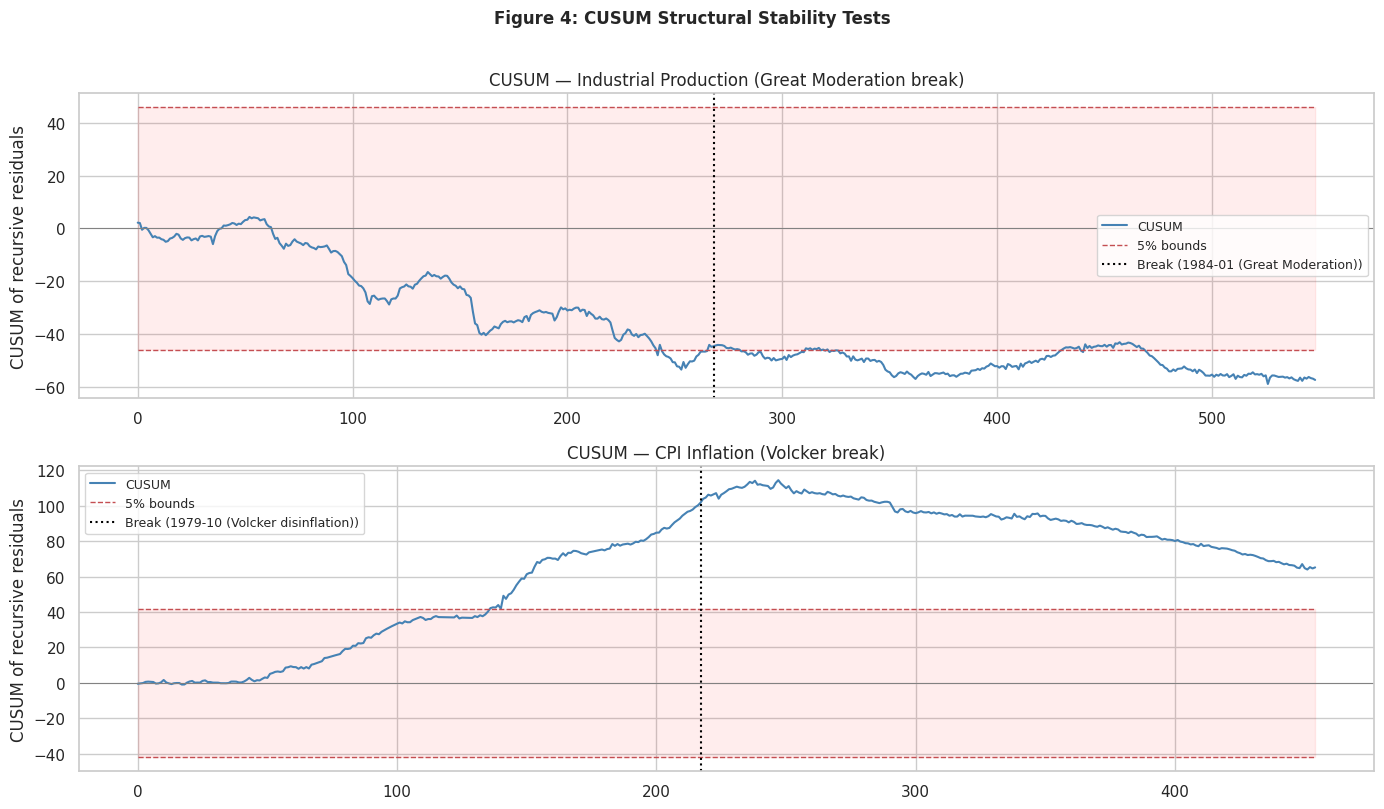

In [12]:
datasets = load_all_datasets()
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, (df_pre, df_post, meta) in zip(axes, datasets):
    df_full = pd.concat([df_pre, df_post], ignore_index=True)
    y_full  = df_full['y'].to_numpy()
    X_full  = df_full[['y_lag1']].assign(const=1.0)[['const', 'y_lag1']].to_numpy()
    cusum   = recursive_cusum(y_full, X_full)
    t = np.arange(len(cusum['cusum']))
    ax.plot(t, cusum['cusum'],       color='steelblue', lw=1.5, label='CUSUM')
    ax.plot(t, cusum['upper_bound'], 'r--', lw=1, label='5% bounds')
    ax.plot(t, cusum['lower_bound'], 'r--', lw=1)
    ax.fill_between(t, cusum['lower_bound'], cusum['upper_bound'], alpha=0.07, color='red')
    ax.axvline(len(df_pre), color='black', ls=':', lw=1.5, label=f"Break ({meta['break']})")
    ax.axhline(0, color='gray', lw=0.7)
    ax.set_title(f"CUSUM — {meta['name']}")
    ax.set_ylabel('CUSUM of recursive residuals')
    ax.legend(fontsize=9)

plt.suptitle('Figure 4: CUSUM Structural Stability Tests',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [13]:
mild_df   = pd.read_csv(SIM_DIR / 'lucas_critique_mild.csv')
severe_df = pd.read_csv(SIM_DIR / 'lucas_critique_severe.csv')
ip_df     = pd.read_csv(DATA_DIR / 'lucas_indpro.csv')
cpi_df    = pd.read_csv(DATA_DIR / 'lucas_cpiaucsl.csv')

combined = (
    mild_df[['model', 'LSR']].rename(columns={'LSR': 'Simulated (Mild)'})
    .merge(severe_df[['model', 'LSR']].rename(columns={'LSR': 'Simulated (Severe)'}), on='model')
    .merge(ip_df[['model', 'LSR']].rename(columns={'LSR': 'INDPRO 1984'}), on='model')
    .merge(cpi_df[['model', 'LSR']].rename(columns={'LSR': 'CPI 1979'}), on='model')
    .sort_values('Simulated (Mild)')
)
combined.to_csv(DATA_DIR / 'lucas_combined.csv', index=False)
print('=== Lucas Sensitivity Ratio: All Experiments ===')
print(combined.to_string(index=False, float_format='{:.3f}'.format))


=== Lucas Sensitivity Ratio: All Experiments ===
                 model  Simulated (Mild)  Simulated (Severe)  INDPRO 1984  CPI 1979
                   HMM             1.509               2.295        0.584     1.133
       Threshold (TAR)             1.644               2.775        0.636     1.190
        AR(2) Baseline             1.656               2.608        0.717     0.986
    Mixture of Experts             1.962               3.541        0.658     1.670
         Model Average             2.468               4.917        0.769     1.291
    ARMA(2,1) Baseline             3.332               6.935        0.634     1.404
Markov Switching (MSM)             3.567               7.148        0.879     1.367
                  MSNN             4.068               5.535        1.513     1.656
       ML Regime (XGB)             8.433              21.406        3.177     7.177


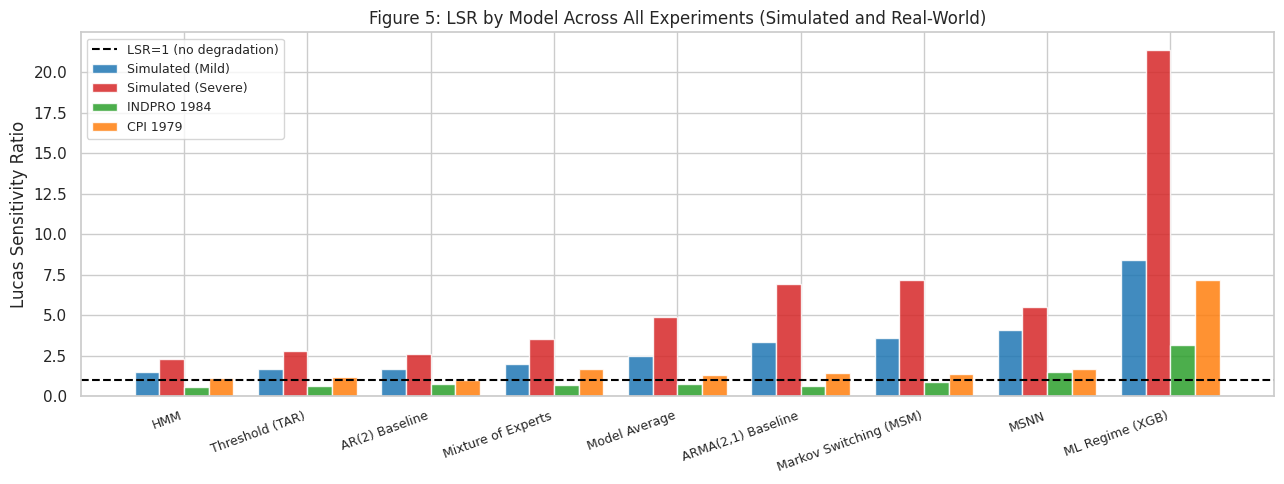

In [14]:
fig, ax = plt.subplots(figsize=(13, 5))
cols_plot = ['Simulated (Mild)', 'Simulated (Severe)', 'INDPRO 1984', 'CPI 1979']
x = np.arange(len(combined))
w = 0.2
colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']
for i, (col, c) in enumerate(zip(cols_plot, colors)):
    ax.bar(x + (i - 1.5) * w, combined[col], w, label=col, color=c, alpha=0.85)
ax.axhline(1.0, color='black', ls='--', lw=1.5, label='LSR=1 (no degradation)')
ax.set_xticks(x)
ax.set_xticklabels(combined['model'], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Lucas Sensitivity Ratio')
ax.set_title('Figure 5: LSR by Model Across All Experiments (Simulated and Real-World)')
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, '05_combined_lsr')
plt.show()


# MAIN RESULTS AND RESULTS SUMMARY

In [15]:
# ── Comprehensive RMSE table — all experiments ──────────────────────────────
from pathlib import Path

SIM_DIR  = PROJECT_ROOT / 'data' / 'simulated'
DATA_DIR = PROJECT_ROOT / 'data' / 'real_world'

mild_df   = pd.read_csv(SIM_DIR  / 'lucas_critique_mild.csv')
severe_df = pd.read_csv(SIM_DIR  / 'lucas_critique_severe.csv')
ip_df     = pd.read_csv(DATA_DIR / 'lucas_indpro.csv')
cpi_df    = pd.read_csv(DATA_DIR / 'lucas_cpiaucsl.csv')

# Model display order
MODEL_ORDER = [
    'AR(2) Baseline', 'ARMA(2,1) Baseline',
    'Markov Switching (MSM)', 'Threshold (TAR)',
    'HMM', 'Mixture of Experts',
    'ML Regime (XGB)', 'MSNN',
    'Model Average',
]

def fmt(row, pre_col, post_col, lsr_col):
    """Format pre / post RMSE with LSR in parentheses."""
    pre  = f"{row[pre_col]:.3f}"
    post = f"{row[post_col]:.3f}"
    lsr  = f"({row[lsr_col]:.2f})"
    return pre, post, lsr

rows = []
for m in MODEL_ORDER:
    r = {'Model': m}
    for df, exp in [(mild_df, 'Sim Mild'), (severe_df, 'Sim Severe'),
                    (ip_df,   'IP 1984'),  (cpi_df,    'CPI 1979')]:
        sub = df[df['model'] == m]
        if sub.empty:
            r[f'{exp} Pre'], r[f'{exp} Post'], r[f'{exp} LSR'] = '—', '—', '—'
        else:
            row = sub.iloc[0]
            r[f'{exp} Pre']  = f"{row['pre_rmse']:.3f}"
            r[f'{exp} Post'] = f"{row['post_rmse']:.3f}"
            r[f'{exp} LSR']  = f"{row['LSR']:.2f}"
    rows.append(r)

tbl = pd.DataFrame(rows).set_index('Model')

# Pretty print
col_groups = ['Sim Mild', 'Sim Severe', 'IP 1984', 'CPI 1979']
headers = ['Model'] + [f"{g}\nPre | Post | LSR" for g in col_groups]

print("=" * 110)
print(f"{'COMPREHENSIVE RMSE TABLE — ALL EXPERIMENTS':^110}")
print("=" * 110)
hdr = f"{'Model':<26}"
for g in col_groups:
    hdr += f"  {g:^26}"
print(hdr)
print(f"{'':26}" + "  " + "  ".join([f"{'Pre':>7}  {'Post':>7}  {'LSR':>6}"] * 4))
print("-" * 110)
for m in MODEL_ORDER:
    line = f"{m:<26}"
    for g in col_groups:
        pre  = tbl.loc[m, f'{g} Pre']
        post = tbl.loc[m, f'{g} Post']
        lsr  = tbl.loc[m, f'{g} LSR']
        line += f"  {pre:>7}  {post:>7}  {lsr:>6}"
    print(line)
print("=" * 110)
print("LSR = post-break RMSE / pre-break RMSE.  LSR < 1 shown in green means improvement post-break.")


                                  COMPREHENSIVE RMSE TABLE — ALL EXPERIMENTS                                  
Model                                Sim Mild                   Sim Severe                   IP 1984                     CPI 1979         
                                Pre     Post     LSR      Pre     Post     LSR      Pre     Post     LSR      Pre     Post     LSR
--------------------------------------------------------------------------------------------------------------
AR(2) Baseline                1.634    2.706    1.66    1.634    4.261    2.61    0.717    0.514    0.72    2.631    2.594    0.99
ARMA(2,1) Baseline            1.674    5.577    3.33    1.674   11.609    6.94    0.811    0.514    0.63    2.533    3.556    1.40
Markov Switching (MSM)        1.673    5.968    3.57    1.673   11.961    7.15    0.823    0.723    0.88    2.954    4.038    1.37
Threshold (TAR)               1.537    2.526    1.64    1.537    4.266    2.78    0.624    0.397    0.64    1.912  

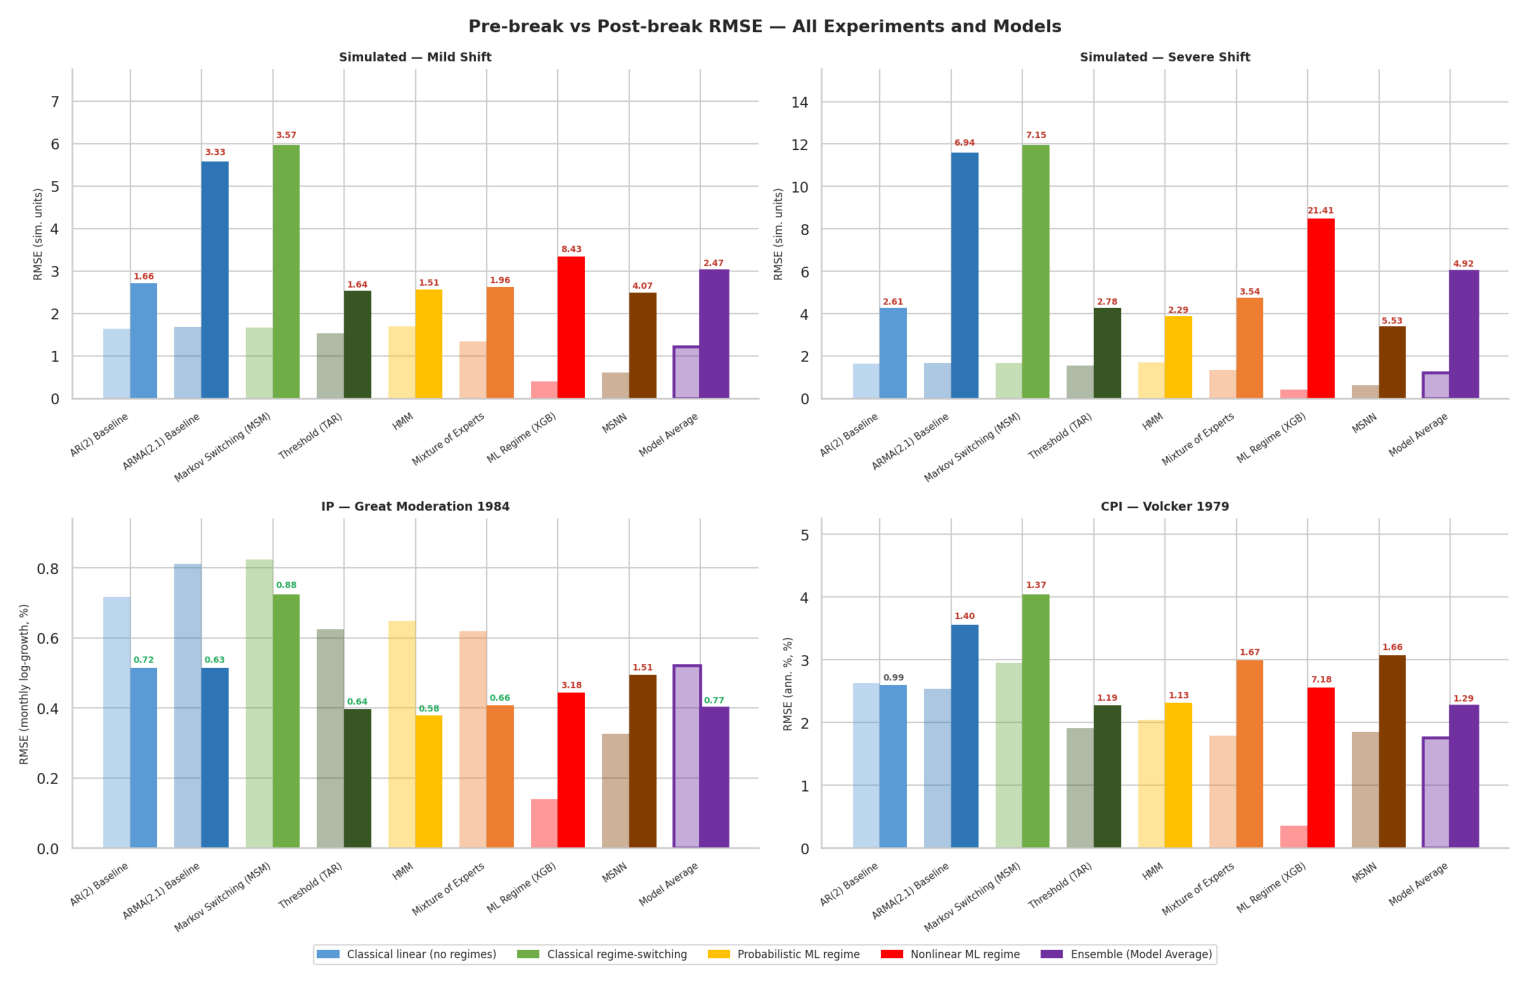

In [16]:
# Display pre-generated 2x2 RMSE overview
fig, ax = plt.subplots(figsize=(16, 10))
path = FIGURES_DIR / '05_rmse_all_experiments.png'
if path.exists():
    import matplotlib.image as mpimg
    ax.imshow(mpimg.imread(str(path))); ax.axis('off')
else:
    ax.text(0.5, 0.5, 'Run the generation cell (rw-run-ip) first', ha='center', va='center')
plt.tight_layout(); plt.show()


### Cross-Experiment Findings

| Finding | Simulated (Mild/Severe) | INDPRO 1984 | CPI 1979 |
|---------|------------------------|-------------|----------|
| All models degrade? | Yes | **No — most improve** | Yes |
| XGB worst? | Yes (8.4 / 21.4) | Yes (3.2) | Yes (7.2) |
| HMM most stable? | Yes (1.51) | Yes (0.58) | Yes (1.13) |
| Chow detects break? | Yes | Yes (F=5.83) | **No** (F=1.39) |

**The direction and magnitude of LSR depends critically on the character of the structural break:**

- Breaks that *increase* DGP volatility → LSR > 1 (classic Lucas Critique)
- Breaks that *decrease* DGP volatility → LSR < 1 (inverse Lucas Critique — a benefit)
- XGB is consistently the most vulnerable model regardless of break type or direction.
- HMM and TAR are consistently the most robust across all experiments.
